In [1]:
# PREAMBLE

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

### BASELINE MODEL

In [2]:
# 0) SETTINGS

DATA_PATH = "withGDP_IRD_with_tone_dataset_jittered.csv"
DATE_COL = "Date"

y_col = "INTERBANK_CALL"

macro_order = [
    "REAL_GDP",
    "WHOLESALE_PRICE",
    "INDUSTRIAL_PRODUCTION",
    "INTERNATIONAL_IMPORTS",
    "INTERNATIONAL_EXPORTS",
    "CPI",
    "EXCHANGE_RATE",
]

ADF_ALPHA = 0.05
KPSS_ALPHA = 0.05
HAC_MAXLAGS = 4

In [3]:
# 1) Load Dataset

df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).set_index(DATE_COL)

rename_map = {
    "INTERBANK CALL LOAN RATE": "INTERBANK_CALL",
    "Real GDP": "REAL_GDP",
    "Wholesale Price": "WHOLESALE_PRICE",
    "Industrial Production": "INDUSTRIAL_PRODUCTION",
    "FX Rate": "EXCHANGE_RATE",
    "Intl Trade Merch Imports": "INTERNATIONAL_IMPORTS",
    "Intl Trade Merch Exports": "INTERNATIONAL_EXPORTS",
    "CPI": "CPI",
}
df = df.rename(columns=rename_map)

base_needed = [y_col] + macro_order
missing = [c for c in base_needed if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in dataset: {missing}")

warnings.simplefilter("always", InterpolationWarning)

In [4]:
# 2) Helper functions

def adf_pvalue(series, autolag="AIC"):
    return adfuller(series.dropna(), autolag=autolag)[1]

def kpss_pvalue(series, regression="c", nlags="auto"):
    return kpss(series.dropna(), regression=regression, nlags=nlags)[1]

def should_difference(adf_p, kpss_p, adf_alpha=ADF_ALPHA, kpss_alpha=KPSS_ALPHA):
    return (adf_p is not None and adf_p > adf_alpha) or (kpss_p is not None and kpss_p < kpss_alpha)

def transform_block(data_block, diff_plan):
    out = pd.DataFrame(index=data_block.index)
    for col in data_block.columns:
        if diff_plan.get(col, False):
            out[f"D_{col}"] = data_block[col].diff()
        else:
            out[col] = data_block[col]
    return out.dropna()

def fit_ols_hac(y, X, hac_lags=HAC_MAXLAGS):
    ols = sm.OLS(y, X).fit()
    hac = ols.get_robustcov_results(cov_type="HAC", maxlags=hac_lags)
    return ols, hac

def diagnostics(ols_res, X):
    vif_df = pd.DataFrame({"variable": X.columns})
    vif_df["VIF"] = [
        np.nan if col == "const" else variance_inflation_factor(X.values, i)
        for i, col in enumerate(X.columns)
    ]
    dw = float(durbin_watson(ols_res.resid))
    bp_lm, bp_lmpval, bp_f, bp_fpval = het_breuschpagan(ols_res.resid, ols_res.model.exog)
    jb_stat, jb_p = stats.jarque_bera(ols_res.resid)
    return {
        "vif_max": float(np.nanmax(vif_df["VIF"].values)),
        "dw": dw,
        "bp_p": float(bp_lmpval),
        "jb_p": float(jb_p),
        "vif_table": vif_df
    }

def extract_params_by_name(results):
    """Return dict: regressor -> (coef, se, p) using exog_names."""
    names = results.model.exog_names
    out = {}
    for i, name in enumerate(names):
        out[name] = (
            float(results.params[i]),
            float(results.bse[i]),
            float(results.pvalues[i]),
        )
    return out

In [5]:
# 3) Stepwise Macro-only Baseline loop

rows = []

for k in range(1, len(macro_order) + 1):
    macros_k = macro_order[:k]
    model_name = " + ".join(macros_k)

    cols = [y_col] + macros_k
    data = df[cols].dropna().copy()

    # Stationarity tests
    stat_rows = []
    for col in cols:
        ap = adf_pvalue(data[col])
        kp = kpss_pvalue(data[col], regression="c")
        stat_rows.append({"variable": col, "ADF p": ap, "KPSS p": kp})
    stat_df = pd.DataFrame(stat_rows)
    diff_plan = {r["variable"]: should_difference(r["ADF p"], r["KPSS p"]) for _, r in stat_df.iterrows()}

    # Transform
    transformed = transform_block(data, diff_plan)

    y_name = f"D_{y_col}" if diff_plan.get(y_col, False) else y_col
    X_cols = [f"D_{c}" if diff_plan.get(c, False) else c for c in macros_k]

    y = transformed[y_name]
    X = sm.add_constant(transformed[X_cols])

    # Fit
    ols, hac = fit_ols_hac(y, X, HAC_MAXLAGS)

    # Diagnostics
    diag = diagnostics(ols, X)

    # Extract coefficients / SE / p-values
    param_dict = extract_params_by_name(hac)

    # Start row with model-level info
    row = {
        "Model": model_name,
        "N": int(hac.nobs),
        "Adj R2": float(hac.rsquared_adj),
        "R2": float(hac.rsquared),
        "AIC": float(ols.aic),
        "BIC": float(ols.bic),
        "DW": diag["dw"],
        "BP p": diag["bp_p"],
        "JB p": diag["jb_p"],
        "VIF max": diag["vif_max"],
        "Regressors": ", ".join(X_cols),
    }

    # Add all available coefficients into the row
    for name, (coef, se, pval) in param_dict.items():
        row[f"coef__{name}"] = coef
        row[f"se__{name}"] = se
        row[f"p__{name}"] = pval

    rows.append(row)

summary = pd.DataFrame(rows)

/tmp/ipykernel_4711/2606730177.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression=regression, nlags=nlags)[1]
/tmp/ipykernel_4711/2606730177.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression=regression, nlags=nlags)[1]
/tmp/ipykernel_4711/2606730177.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression=regression, nlags=nlags)[1]
/tmp/ipykernel_4711/2606730177.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller th

In [6]:
# 4) Pretty display

summary_disp = summary.copy()
for c in ["Adj R2", "R2", "AIC", "BIC"]:
    summary_disp[c] = summary_disp[c].map(lambda x: f"{x:.4f}")
summary_disp["DW"] = summary_disp["DW"].map(lambda x: f"{x:.3f}")
summary_disp["BP p"] = summary_disp["BP p"].map(lambda x: f"{x:.4f}")
summary_disp["JB p"] = summary_disp["JB p"].map(lambda x: f"{x:.4f}")
summary_disp["VIF max"] = summary_disp["VIF max"].map(lambda x: f"{x:.2f}")

print("\n=== Stepwise macro-only baseline results (HAC inference) ===")
print(summary_disp[[
    "Model", "N", "Adj R2", "R2", "AIC", "BIC", "DW", "BP p", "VIF max"
]].to_string(index=False))


=== Stepwise macro-only baseline results (HAC inference) ===
                                                                                                                   Model   N  Adj R2     R2       AIC       BIC    DW   BP p VIF max
                                                                                                                REAL_GDP 227 -0.0042 0.0002 -125.4835 -118.6336 1.449 0.7642    1.00
                                                                                              REAL_GDP + WHOLESALE_PRICE 227  0.0080 0.0168 -127.2693 -116.9945 1.470 0.9491    1.02
                                                                      REAL_GDP + WHOLESALE_PRICE + INDUSTRIAL_PRODUCTION 227  0.0915 0.1036 -146.2608 -132.5610 1.606 0.5855    1.03
                                              REAL_GDP + WHOLESALE_PRICE + INDUSTRIAL_PRODUCTION + INTERNATIONAL_IMPORTS 227  0.1064 0.1222 -149.0270 -131.9022 1.561 0.1600    1.08
                      REAL_GDP + 

In [7]:
# 5) Export CSV

out_csv = "stepwise_macro_only_results_with_betas.csv"
summary.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

# Optional detailed view
print("\n=== Detailed macro-only view ===")
print(summary.to_string(index=False))


Saved: stepwise_macro_only_results_with_betas.csv

=== Detailed macro-only view ===
                                                                                                                   Model   N    Adj R2       R2         AIC         BIC       DW     BP p         JB p  VIF max                                                                                                                   Regressors  coef__const  se__const  p__const  coef__D_REAL_GDP  se__D_REAL_GDP  p__D_REAL_GDP  coef__D_WHOLESALE_PRICE  se__D_WHOLESALE_PRICE  p__D_WHOLESALE_PRICE  coef__INDUSTRIAL_PRODUCTION  se__INDUSTRIAL_PRODUCTION  p__INDUSTRIAL_PRODUCTION  coef__D_INTERNATIONAL_IMPORTS  se__D_INTERNATIONAL_IMPORTS  p__D_INTERNATIONAL_IMPORTS  coef__INTERNATIONAL_EXPORTS  se__INTERNATIONAL_EXPORTS  p__INTERNATIONAL_EXPORTS  coef__D_CPI  se__D_CPI  p__D_CPI  coef__D_EXCHANGE_RATE  se__D_EXCHANGE_RATE  p__D_EXCHANGE_RATE
                                                                               

### AUGMENTED MODEL - FULL PIPELINE

In [8]:
# 0) Load again

DATA_PATH = "withGDP_IRD_with_tone_dataset_jittered.csv"
y_col = "INTERBANK_CALL"

TONE_SPECS = {
    "Negative_Only": ["neg_mean_jittered"],
    "Neutral_Only":  ["neu_mean_jittered"],
    "Net_Tone":      ["tone_mean_jittered"],
    "Asymmetry":     ["pos_mean_jittered", "neg_mean_jittered"]
}

macro_order = ["REAL_GDP", "WHOLESALE_PRICE", "INDUSTRIAL_PRODUCTION",
               "INTERNATIONAL_IMPORTS", "INTERNATIONAL_EXPORTS", "CPI", "EXCHANGE_RATE"]

ADF_ALPHA = 0.05
KPSS_ALPHA = 0.05
HAC_MAXLAGS = 4

In [9]:
# 1) Data rename

df = pd.read_csv(DATA_PATH)
rename_map = {
    "INTERBANK CALL LOAN RATE": "INTERBANK_CALL",
    "Real GDP": "REAL_GDP",
    "Wholesale Price": "WHOLESALE_PRICE",
    "Industrial Production": "INDUSTRIAL_PRODUCTION",
    "FX Rate": "EXCHANGE_RATE",
    "Intl Trade Merch Imports": "INTERNATIONAL_IMPORTS",
    "Intl Trade Merch Exports": "INTERNATIONAL_EXPORTS",
    "CPI": "CPI",
}
df = df.rename(columns=rename_map)
df['Date'] = pd.to_datetime(df['Date']).sort_values()
df = df.set_index('Date')

In [10]:
# 2) Helper functions

def adf_pvalue(series):
    return adfuller(series.dropna(), autolag="AIC")[1]

def kpss_pvalue(series):
    return kpss(series.dropna(), regression="c", nlags="auto")[1]

def should_difference(adf_p, kpss_p):
    return (adf_p > ADF_ALPHA) or (kpss_p < KPSS_ALPHA)


In [11]:
# 3) Loop

for spec_name, tone_cols in TONE_SPECS.items():
    print(f"\n{'='*60}\nRUNNING SPECIFICATION: {spec_name}\n{'='*60}")

    rows = []

    for k in range(1, len(macro_order) + 1):
        macros_k = macro_order[:k]
        current_cols = [y_col] + tone_cols + macros_k
        data = df[current_cols].dropna().copy()

        # STATIONARITY ANALYSIS
        diff_plan = {}
        for col in current_cols:
            ap = adf_pvalue(data[col])
            kp = kpss_pvalue(data[col])
            diff_plan[col] = should_difference(ap, kp)

        # TRANSFORM
        transformed = pd.DataFrame(index=data.index)
        for col in current_cols:
            if diff_plan[col]:
                transformed[f"D_{col}"] = data[col].diff()
            else:
                transformed[col] = data[col]
        transformed = transformed.dropna()

        # Define Regressors
        y_name = f"D_{y_col}" if diff_plan[y_col] else y_col
        tone_terms = [f"D_{c}" if diff_plan[c] else c for c in tone_cols]
        macro_terms = [f"D_{c}" if diff_plan[c] else c for c in macros_k]

        y = transformed[y_name]
        X_with = sm.add_constant(transformed[tone_terms + macro_terms])
        X_base = sm.add_constant(transformed[macro_terms])

        # FIT MODELS
        hac_with = sm.OLS(y, X_with).fit().get_robustcov_results(cov_type="HAC", maxlags=HAC_MAXLAGS)
        hac_base = sm.OLS(y, X_base).fit().get_robustcov_results(cov_type="HAC", maxlags=HAC_MAXLAGS)

        # STANDARDIZED BETAS
        y_std = (y - y.mean()) / y.std()
        X_std = (X_with - X_with.mean()) / X_with.std()
        X_std['const'] = 1
        beta_res = sm.OLS(y_std, X_std).fit()

        # RESULTS EXTRACTION
        for t_var in tone_terms:
            t_idx = X_with.columns.tolist().index(t_var)

            rows.append({
                "Spec": spec_name,
                "Macro_K": k,
                "N": int(hac_with.nobs),
                "Tone_Var": t_var,
                "Coef": hac_with.params[t_idx],
                "Beta": beta_res.params[t_idx],
                "p-val": hac_with.pvalues[t_idx],
                "R2": hac_with.rsquared,           # Total R-squared
                "AdjR2": hac_with.rsquared_adj,    # Total Adjusted R-squared
                "Delta_AdjR2": hac_with.rsquared_adj - hac_base.rsquared_adj,
                "VIF": variance_inflation_factor(X_with.values, t_idx)
            })

    # Save CSV
    spec_results = pd.DataFrame(rows)
    spec_results.to_csv(f"Results_{spec_name}.csv", index=False)
    print(f"Saved: Results_{spec_name}.csv")

print("\nTask completed: R-squared and Adjusted R-squared added to outputs.")


RUNNING SPECIFICATION: Negative_Only


/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1717274862.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": beta_res.params[t_idx],
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-v

Saved: Results_Negative_Only.csv

RUNNING SPECIFICATION: Neutral_Only


/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value ret

Saved: Results_Neutral_Only.csv

RUNNING SPECIFICATION: Net_Tone


/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1717274862.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": beta_res.params[t_idx],
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-v

Saved: Results_Net_Tone.csv

RUNNING SPECIFICATION: Asymmetry


/tmp/ipykernel_4711/1717274862.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": beta_res.params[t_idx],
/tmp/ipykernel_4711/1717274862.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": beta_res.params[t_idx],
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available 

Saved: Results_Asymmetry.csv

Task completed: R-squared and Adjusted R-squared added to outputs.


/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1546494991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_4711/1717274862.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent wit

## GRAPHS AND VISUALIZATIONS

<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4711/3067336867.py:12: SyntaxWarning: invalid escape sequence '\g'
  capsize=5, markersize=8, label='Coefficient ($\gamma$) with 90% CI')
/tmp/ipykernel_4711/3067336867.py:16: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('Estimated Coefficient ($\gamma$)', fontsize=12)
/tmp/ipykernel_4711/3067336867.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Figure A: Impact of Central Bank Tone on $\Delta$ICLR\n(Full Macro Controls)', fontsize=14)


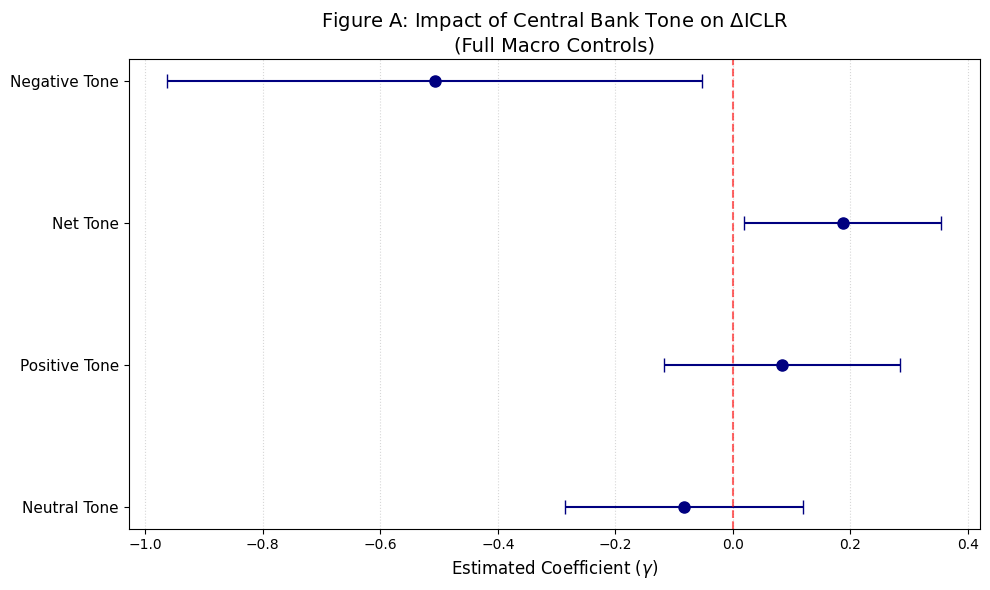

In [19]:
df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

specs = ['Neutral Tone', 'Positive Tone', 'Net Tone', 'Negative Tone']
coefs = [-0.0831, 0.0838, 0.1868, -0.5072]

se = [0.1235, 0.1223, 0.1022, 0.2768]
ci_90 = [1.645 * s for s in se]

plt.figure(figsize=(10, 6))
plt.errorbar(coefs, range(len(specs)), xerr=ci_90, fmt='o', color='navy',
             capsize=5, markersize=8, label='Coefficient ($\gamma$) with 90% CI')

plt.axvline(0, color='red', linestyle='--', alpha=0.6)
plt.yticks(range(len(specs)), specs, fontsize=11)
plt.xlabel('Estimated Coefficient ($\gamma$)', fontsize=12)
plt.title('Figure A: Impact of Central Bank Tone on $\Delta$ICLR\n(Full Macro Controls)', fontsize=14)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('figure_a_coefficient_plot.png')

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4711/2050763089.py:16: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta$ICLR (6-Mo Smoothed, Basis Points)', color=color_iclr, fontsize=12, fontweight='bold')
/tmp/ipykernel_4711/2050763089.py:17: SyntaxWarning: invalid escape sequence '\D'
  line2 = ax2.plot(df['Date'], df['iclr_smooth'], color=color_iclr, linewidth=2, label='$\Delta$ICLR', alpha=0.7)


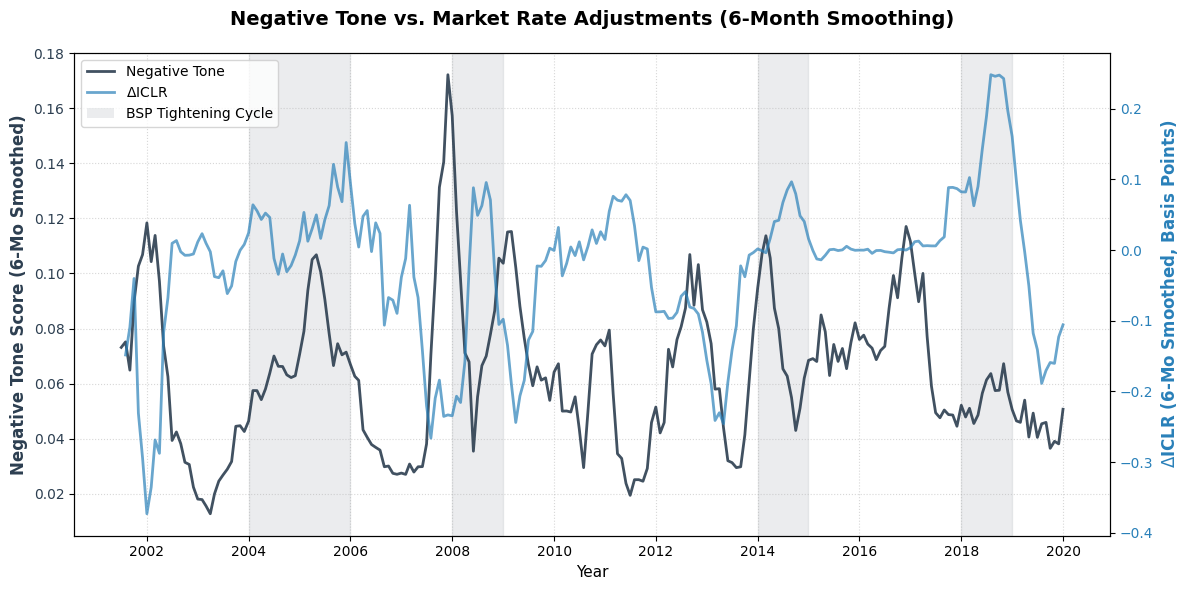

In [23]:
window_size = 6
df['iclr_diff'] = df['INTERBANK CALL LOAN RATE'].diff()
df['iclr_smooth'] = df['iclr_diff'].rolling(window=window_size, center=True).mean()
df['neg_smooth'] = df['neg_mean_jittered'].rolling(window=window_size, center=True).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

color_tone = '#2c3e50'
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Negative Tone Score (6-Mo Smoothed)', color=color_tone, fontsize=12, fontweight='bold')
line1 = ax1.plot(df['Date'], df['neg_smooth'], color=color_tone, linewidth=2, label='Negative Tone', alpha=0.9)
ax1.tick_params(axis='y', labelcolor=color_tone)

ax2 = ax1.twinx()
color_iclr = '#2980b9'
ax2.set_ylabel('$\Delta$ICLR (6-Mo Smoothed, Basis Points)', color=color_iclr, fontsize=12, fontweight='bold')
line2 = ax2.plot(df['Date'], df['iclr_smooth'], color=color_iclr, linewidth=2, label='$\Delta$ICLR', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_iclr)

tightening_cycles = [
    ('2004-01-01', '2005-12-31'),
    ('2008-01-01', '2008-12-31'),
    ('2014-01-01', '2014-12-31'),
    ('2018-01-01', '2018-12-31')
]

for start, end in tightening_cycles:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='#bdc3c7', alpha=0.3)

legend_elements = [
    line1[0],
    line2[0],
    Patch(facecolor='#bdc3c7', alpha=0.3, label='BSP Tightening Cycle')
]
ax1.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=10)

plt.title('Negative Tone vs. Market Rate Adjustments (6-Month Smoothing)',
          fontsize=14, pad=20, fontweight='bold')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

fig.tight_layout()
plt.savefig('Figure_C_Final_Smoothed.png', dpi=300)
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4711/4266062004.py:26: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta$ICLR Residuals\n(Controlled for all 7 Macro Variables)', fontsize=11)


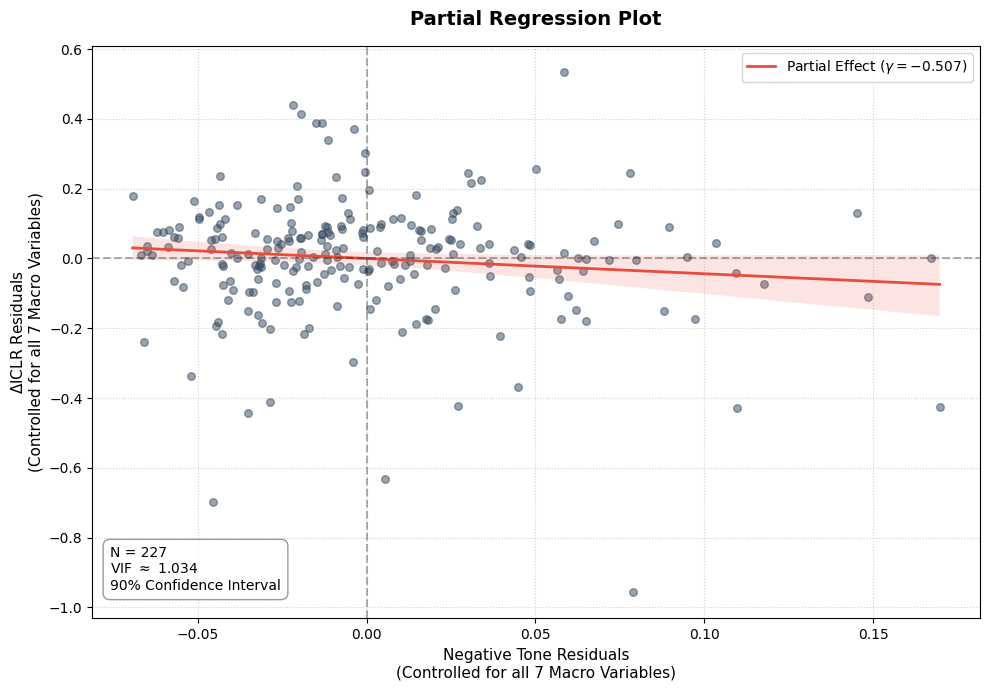

In [24]:
x_var = 'neg_mean_jittered'

controls = [
    'Real GDP', 'CPI', 'Wholesale Price', 'Industrial Production',
    'Intl Trade Merch Exports', 'Intl Trade Merch Imports', 'FX Rate'
]

plot_data = df[['iclr_diff', x_var] + controls].dropna()

X_macro = sm.add_constant(plot_data[controls])
res_y = sm.OLS(plot_data['iclr_diff'], X_macro).fit().resid

res_x = sm.OLS(plot_data[x_var], X_macro).fit().resid

plt.figure(figsize=(10, 7))

sns.regplot(x=res_x, y=res_y, ci=90,
            scatter_kws={'alpha': 0.5, 'color': '#34495e', 's': 30},
            line_kws={'color': '#e74c3c', 'linewidth': 2, 'label': r'Partial Effect ($\gamma = -0.507$)'})

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

plt.title('Partial Regression Plot', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Negative Tone Residuals\n(Controlled for all 7 Macro Variables)', fontsize=11)
plt.ylabel('$\Delta$ICLR Residuals\n(Controlled for all 7 Macro Variables)', fontsize=11)

plt.annotate(f'N = {len(plot_data)}\nVIF $\\approx$ 1.034\n90% Confidence Interval',
             xy=(0.02, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
             fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('Figure_D_Final.png', dpi=300)
plt.show()